# **PENERAPAN METODE LONG SHORT TERM MEMORY UNTUK ANALISIS SENTIMEN ULASAN APLIAKSI BCA MOBILE DI GOOGLE PLAY**


Blok Inisialisasi Pustaka (Library Initialization Block) atau Blok Persiapan Lingkungan (Environment Setup Block) untuk proyek Analisis Sentimen dengan fokus pada Natural Language Processing (NLP) Bahasa Indonesia.

In [ ]:
import pandas as pd
import re
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

!pip install sastrawi
# from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
# Membuat objek stemmer sekali dan menyimpannya di variabel global
factory = StemmerFactory()
GLOBAL_STEMMER = factory.create_stemmer()
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.
nltk.download('punkt_tab') # Mengunduh resource 'punkt_tab' untuk tokenisasi kalimat.
!pip install gdown

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# **Membaca hasil scrapped data ulasan aplikasi BCA mobile file CSV**

In [ ]:
# Baca file CSV
df = pd.read_csv('scrapped_data_BCA.csv')
df.head()

,userName,at,content;
0,Pengguna Google,2025-01-22 11:26:03,Cept kaya lo.. Jaringan bagus. Bilang gk ada k...
1,"Pengguna Google,2025-01-22 09:57:43,""knp harus...",NaN,NaN
2,Pengguna Google,2025-01-22 09:55:48,Kok ini ngga bisa di update yaa;
3,Pengguna Google,2025-01-22 08:12:25,Ok;
4,Pengguna Google,2025-01-22 07:40:13,Sangat membatu aktifotas saya;


# ***EXPLORE***

**Memvisualisasikan data ulasan dalam bentuk diagram batang per minggu**

/tmp/ipykernel_8801/1045853142.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=ulasan_per_minggu, x='Minggu_Label', y='Jumlah_Ulasan', palette='viridis', edgecolor='black')


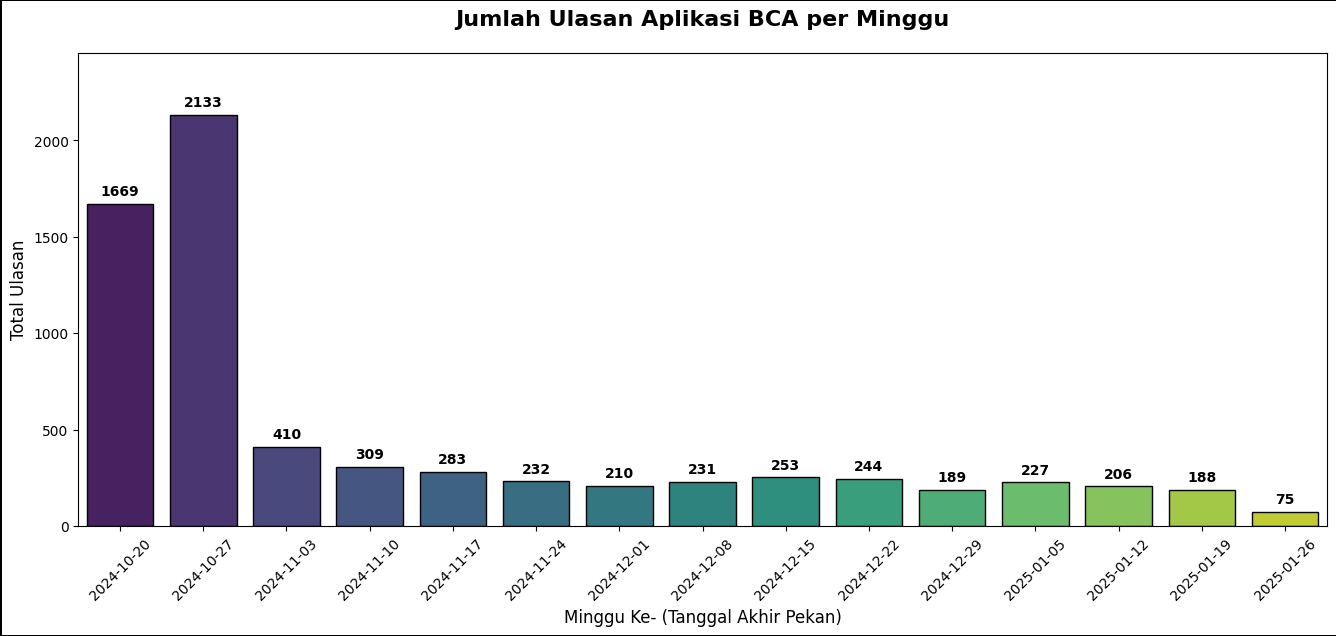

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# memastikan daftar kolom bersih
df.columns = df.columns.str.replace(';', '').str.strip()
df['at'] = pd.to_datetime(df['at'])

# Resample data per minggu
ulasan_per_minggu = df.resample('W', on='at')['content'].count().reset_index()
ulasan_per_minggu.columns = ['Minggu', 'Jumlah_Ulasan']
ulasan_per_minggu['Minggu_Label'] = ulasan_per_minggu['Minggu'].dt.strftime('%Y-%m-%d')

# linewidth dan edgecolor di sini akan membuat bingkai luar
fig = plt.figure(figsize=(14, 7), linewidth=2, edgecolor='black')

# 2. Membuat Grafik
ax = sns.barplot(data=ulasan_per_minggu, x='Minggu_Label', y='Jumlah_Ulasan', palette='viridis', edgecolor='black')

# Menampilkan angka detail di atas batang
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=10, fontweight='bold')

# 3. Mempercantik Tampilan
plt.title('Jumlah Ulasan Aplikasi BCA per Minggu', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Minggu Ke- (Tanggal Akhir Pekan)', fontsize=12)
plt.ylabel('Total Ulasan', fontsize=12)

plt.xticks(rotation=45)
plt.ylim(0, ulasan_per_minggu['Jumlah_Ulasan'].max() * 1.15)

# 4. Menyesuaikan layout agar bingkai terlihat rapi
plt.tight_layout(pad=3.0)

plt.show()

In [ ]:
df.dropna(inplace=True)
clean_df = df
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6859 entries, 0 to 9998
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   userName  6859 non-null   object        
 1   at        6859 non-null   datetime64[ns]
 2   content   6859 non-null   object        
dtypes: datetime64[ns](1), object(2)
memory usage: 214.3+ KB


# ***MODIFY***

# **Text Preprocessing**

**cleaning**

Cleaning adalah sebuah blok kode Pra-pemrosesan Teks (Text Pre-processing) yang spesifik ditujukan untuk membersihkan data ulasan sebelum dianalisis lebih lanjut, seperti untuk analisis sentimen. Tujuan utama dari fungsi ini adalah untuk memastikan bahwa hanya kata-kata bermakna yang tersisa dalam teks, sehingga model analisis sentimen (baik leksikon maupun machine learning) tidak terdistraksi oleh karakter, simbol, atau pola teks yang tidak relevan.

In [ ]:
def cleaning(text):
    text = text.lower()

    # 2. Menghapus elemen spesifik (Mention, Hashtag, RT, Link)
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'rt[\s]', '', text)
    text = re.sub(r"http\S+", '', text)

    # 3. Menghapus Huruf Berulang (Elongated Words)
    # Contoh: "bbuuuusssseeetttt" -> "buset"
    text = re.sub(r'(\w)\1{2,}', r'\1', text)

    # 4. Menghapus Angka
    text = re.sub(r'[0-9]+', '', text)

    # 5. Menghapus Tanda Baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 6. Membersihkan Spasi & Newline
    text = text.replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text) # Mengubah spasi ganda menjadi satu spasi
    text = text.strip()

    return text

# Uji Coba
input_alay = "BCA kenapa suka tiap bulan nya leeeemooooottttt bbuuuusssseeetttt!!!!"
print(f"Hasil: {cleaning(input_alay)}")

Hasil: bca kenapa suka tiap bulan nya lemot bbuset


**casefolding**

Casefolding adalah salah satu langkah Pra-pemrosesan Teks (Text Pre-processing) yang paling sederhana namun mendasar. Tujuan dari fungsi ini adalah untuk mengubah semua karakter dalam teks menjadi huruf kecil (lowercase).

In [ ]:
def casefolding(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

**tokenizing**

Tokenizing (atau Tokenisasi) adalah langkah dalam Natural Language Processing (NLP) yang bertujuan untuk memecah string teks menjadi unit-unit yang lebih kecil dan bermakna, yang disebut token.

In [ ]:
def tokenizing(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

**Stopword**

Stopword adalah langkah pra-pemrosesan teks (Text Pre-processing) dalam Natural Language Processing (NLP) yang secara spesifik merujuk pada proses menghapus kata-kata yang tidak memiliki makna atau nilai informasi signifikan dari teks.

In [ ]:
import nltk
from nltk.corpus import stopwords

# 1. Inisialisasi daftar stopwords
stop_words = set(stopwords.words('indonesian'))
stop_words.update(stopwords.words('english'))

# 2. Daftar KATA NEGASI yang HARUS DIPERTAHANKAN
# Penambahan negasi untuk menjaga ini agar tidak terhapus dari daftar stop_words agar tidak ikut terbuang
negations = {'tidak', 'kurang', 'belum', 'jangan', 'gagal', 'tak'}
stop_words = stop_words.difference(negations)

# 3. Penambahan kata-kata kustom (slang/tambahan yang tidak penting)
custom_words = {
    'iya', 'yaa', 'nya', 'na', 'sih', 'ku', 'di', 'ya',
    'gaa', 'loh', 'kah', 'woi', 'woii', 'woy', 'ng', 'ny'
}
stop_words.update(custom_words)

def filtering(text_list):
    """
    Menghapus stopwords dari list kata, tapi tetap mempertahankan negasi.
    """
    return [txt for txt in text_list if txt.lower() not in stop_words]

# ---Contoh cara Penggunaan (Testing) ---
data_input = ["Aplikasi", "ini", "tidak", "bagus", "dan", "kurang", "membantu", "ya", "ng"]
data_output = filtering(data_input)

print("Input  :", data_input)
print("Output :", data_output)

Input  : ['Aplikasi', 'ini', 'tidak', 'bagus', 'dan', 'kurang', 'membantu', 'ya', 'ng']
Output : ['Aplikasi', 'tidak', 'bagus', 'kurang', 'membantu']


**stemming**

Stemming adalah proses untuk mengubah kata berimbuhan menjadi bentuk kata dasarnya (akar kata), terlepas dari imbuhan (awalan, sisipan, atau akhiran) yang melekat padanya.

Stemmer Global adalah praktik pemrograman di mana objek yang bertugas melakukan stemming (pencarian akar kata), seperti objek yang dibuat dari library Sastrawi, diinisialisasi hanya sekali dan disimpan dalam sebuah variabel yang dapat diakses dari mana saja dalam program (variabel global).

Menggunakan objek stemmer yang sama secara global menjamin bahwa setiap baris teks ulasan akan diproses menggunakan set aturan yang persis sama. Ini menghilangkan risiko variasi atau bug yang mungkin muncul jika objek stemmer dibuat ulang dengan konfigurasi memori atau lingkungan yang sedikit berbeda, sehingga memastikan hasil stemming konsisten dan andal untuk semua data yang akan dimasukkan ke model analisis sentimen.

In [ ]:
def stemming(text):
    # 'text' diasumsikan sebagai list of tokens (misalnya dari kolom 'stopword')
    stemmed_words = [GLOBAL_STEMMER.stem(word) for word in text]
    return stemmed_words # Kembalikan list tokens

**Normalize**

Langkah Slangword dalam pre-processing adalah tahap yang wajib dilakukan untuk menormalisasi bahasa tidak baku menjadi bahasa standar (baku) sebelum data diproses lebih lanjut.

In [ ]:
normalize_df = pd.read_csv('slang_words.csv')
# Konversi DataFrame menjadi dictionary untuk pencarian cepat
normalization = pd.Series(normalize_df.formal.values, index=normalize_df.slang).to_dict()
print(f"Total {len(normalization)} pasangan slangword dimuat.")

def fix_normalization(text):
    words = text.split()
    fixed_words = []

    for word in words:
        # Mencari kata di kamus slangwords (yang sudah dimuat dari CSV)
        if word in normalization:
            fixed_words.append(normalization[word])
        else:
            fixed_words.append(word)

    return ' '.join(fixed_words)

Total 5124 pasangan slangword dimuat.


**Penggabungan token menjadi kalimat**

Fungsi toSentence(list_words) adalah langkah Normalisasi Teks terakhir dalam pipeline pra-pemrosesan Anda. Tujuannya adalah untuk menggabungkan kembali daftar kata-kata (tokens) menjadi sebuah kalimat tunggal (string).

In [ ]:
def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

# **Pipeline**

mendefinisikan dan menerapkan alur kerja (pipeline) lengkap untuk Pra-pemrosesan Teks (Text Pre-processing) pada DataFrame Pandas (clean_df).
Setiap baris kode menjalankan satu tahap pemrosesan dan menyimpan hasilnya dalam kolom baru, membangun data yang semakin bersih secara bertahap.

In [ ]:
clean_df['cleaning'] = clean_df['content'].apply(cleaning)

clean_df['casefolding'] = clean_df['cleaning'].apply(casefolding)

clean_df['normalization'] = clean_df['casefolding'].apply(fix_normalization)

clean_df['tokenizing'] = clean_df['normalization'].apply(tokenizing)

clean_df['stopword'] = clean_df['tokenizing'].apply(filtering)

clean_df['stemming'] = clean_df['stopword'].apply(stemming)

clean_df['text_akhir'] = clean_df['stemming'].apply(toSentence)

display(clean_df)

,userName,at,content,cleaning,casefolding,normalization,tokenizing,stopword,stemming,text_akhir
0,Pengguna Google,2025-01-22 11:26:03,Cept kaya lo.. Jaringan bagus. Bilang gk ada k...,cept kaya lo jaringan bagus bilang gk ada kone...,cept kaya lo jaringan bagus bilang gk ada kone...,cepat kayak kamu jaringan bagus bilang tidak a...,"[cepat, kayak, kamu, jaringan, bagus, bilang, ...","[cepat, kayak, jaringan, bagus, bilang, tidak,...","[cepat, kayak, jaring, bagus, bilang, tidak, k...",cepat kayak jaring bagus bilang tidak koneksi ...
2,Pengguna Google,2025-01-22 09:55:48,Kok ini ngga bisa di update yaa;,kok ini ngga bisa di update yaa,kok ini ngga bisa di update yaa,kok ini tidak bisa di update ya,"[kok, ini, tidak, bisa, di, update, ya]","[tidak, update]","[tidak, update]",tidak update
3,Pengguna Google,2025-01-22 08:12:25,Ok;,ok,ok,ok,[ok],[ok],[ok],ok
4,Pengguna Google,2025-01-22 07:40:13,Sangat membatu aktifotas saya;,sangat membatu aktifotas saya,sangat membatu aktifotas saya,sangat membantu aktivitas saya,"[sangat, membantu, aktivitas, saya]","[membantu, aktivitas]","[bantu, aktivitas]",bantu aktivitas
5,Pengguna Google,2025-01-22 06:17:16,Ko gak bisa kebuka....jadi eror gini mbanking ...,ko gak bisa kebukajadi eror gini mbanking bca,ko gak bisa kebukajadi eror gini mbanking bca,kok enggak bisa kebuka jadi error begini mbank...,"[kok, enggak, bisa, kebuka, jadi, error, begin...","[kebuka, error, mbanking, baca]","[buka, error, mbanking, baca]",buka error mbanking baca
...,...,...,...,...,...,...,...,...,...,...
9990,Josapat Barus,2024-10-19 06:28:25,Aplikasi lg error kah?;,aplikasi lg error kah,aplikasi lg error kah,aplikasi lagi error kah,"[aplikasi, lagi, error, kah]","[aplikasi, error]","[aplikasi, error]",aplikasi error
9994,hyena wijaya,2024-10-19 06:27:39,kenapa saya buka aplikasi bca mobile tidak bis...,kenapa saya buka aplikasi bca mobile tidak bis...,kenapa saya buka aplikasi bca mobile tidak bis...,kenapa saya buka aplikasi baca mobile tidak bi...,"[kenapa, saya, buka, aplikasi, baca, mobile, t...","[buka, aplikasi, baca, mobile, tidak, langsung...","[buka, aplikasi, baca, mobile, tidak, langsung...",buka aplikasi baca mobile tidak langsung tutup
9995,AHMAD RIZQI,2024-10-19 06:27:28,Banyak nya ng bug;,banyak nya ng bug,banyak nya ng bug,banyak nya ng bug,"[banyak, nya, ng, bug]",[bug],[bug],bug
9997,Dimas Apriana,2024-10-19 06:26:10,Good;,good,good,good,[good],[good],[good],good


**Menyimpan dataset hasil dari text preprocessing**

In [ ]:
clean_df.to_csv('dataset_preprocesing.csv', index=False)

# **Pelabelan**

Inisialisasi Kamus Leksikon Sentimen Lokal untuk analisis sentimen.
Tujuan utama dari kode ini adalah untuk memuat kamus kata-kata sentimen positif dan negatif dari file CSV lokal ke dalam struktur data yang dapat diakses dan digunakan dengan cepat oleh program, yaitu Python Dictionary.

In [ ]:
import csv

# --- Membaca data kamus kata-kata positif dari FILE LOKAL ---
lexicon_positive = dict()
file_positive_name = 'lexicon_positive.csv' # Pastikan nama file ini benar

try:
    # Membuka file CSV lokal untuk dibaca ('r' - read)
    with open(file_positive_name, 'r', encoding='utf-8') as csvfile:
        # Membaca file CSV dengan pemisah koma
        reader = csv.reader(csvfile, delimiter=',')

        for row in reader:
            # Pastikan baris memiliki setidaknya 2 kolom sebelum diakses
            if len(row) >= 2:
                # Menambahkan kata-kata positif dan skornya ke dalam kamus
                lexicon_positive[row[0].strip()] = int(row[1].strip())

except FileNotFoundError:
    print(f"Error: File {file_positive_name} tidak ditemukan. Pastikan file ada di direktori yang benar.")
except Exception as e:
    print(f"Terjadi kesalahan saat membaca {file_positive_name}: {e}")


# --- Membaca data kamus kata-kata negatif dari FILE LOKAL ---
lexicon_negative = dict()
file_negative_name = 'lexicon_negative.csv' # Pastikan nama file ini benar

try:
    # Membuka file CSV lokal untuk dibaca ('r' - read)
    with open(file_negative_name, 'r', encoding='utf-8') as csvfile:
        # Membaca file CSV dengan pemisah koma
        reader = csv.reader(csvfile, delimiter=',')

        for row in reader:
            # Pastikan baris memiliki setidaknya 2 kolom sebelum diakses
            if len(row) >= 2:
                # Menambahkan kata-kata negatif dan skornya ke dalam kamus
                lexicon_negative[row[0].strip()] = int(row[1].strip())

except FileNotFoundError:
    print(f"Error: File {file_negative_name} tidak ditemukan. Pastikan file ada di direktori yang benar.")
except Exception as e:
    print(f"Terjadi kesalahan saat membaca {file_negative_name}: {e}")

print(f"Jumlah kata positif dimuat: {len(lexicon_positive)}")
print(f"Jumlah kata negatif dimuat: {len(lexicon_negative)}")

Jumlah kata positif dimuat: 2666
Jumlah kata negatif dimuat: 4975


mendefinisikan ulang fungsi sentiment_analysis_lexicon_indonesia untuk menentukan polaritas sentimen sebuah ulasan berdasarkan kamus kata (lexicon-based approach).

In [ ]:
# Fungsi untuk menentukan polaritas sentimen dari ulasan BCA mobile

def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:

    score = 0
    # Inisialisasi skor sentimen ke 0

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

    polarity=''
    # Inisialisasi variabel polaritas

    if score > 0:
        polarity = 'positive'
        # Jika skor sentimen lebih besar dari 0, maka polaritas adalah positif
    elif score < 0:
        polarity = 'negative'
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif
    else:
        polarity = 'neutral'
    # Jika skor sentimen tepat 0, maka polaritas adalah netral

    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

# **Hasil polarity sentimen**

menggunakan data dari hasil stemming karena data tersebut sudah bersih dari Noise dan telah melewati langkah langkah sebelumnya pada pre-processing

In [ ]:
results = clean_df['stemming'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negative    2990
positive    2862
neutral     1007
Name: count, dtype: int64


In [ ]:
display(clean_df)

,userName,at,content,cleaning,casefolding,normalization,tokenizing,stopword,stemming,text_akhir,polarity_score,polarity
0,Pengguna Google,2025-01-22 11:26:03,Cept kaya lo.. Jaringan bagus. Bilang gk ada k...,cept kaya lo jaringan bagus bilang gk ada kone...,cept kaya lo jaringan bagus bilang gk ada kone...,cepat kayak kamu jaringan bagus bilang tidak a...,"[cepat, kayak, kamu, jaringan, bagus, bilang, ...","[cepat, kayak, jaringan, bagus, bilang, tidak,...","[cepat, kayak, jaring, bagus, bilang, tidak, k...",cepat kayak jaring bagus bilang tidak koneksi ...,-18,negative
2,Pengguna Google,2025-01-22 09:55:48,Kok ini ngga bisa di update yaa;,kok ini ngga bisa di update yaa,kok ini ngga bisa di update yaa,kok ini tidak bisa di update ya,"[kok, ini, tidak, bisa, di, update, ya]","[tidak, update]","[tidak, update]",tidak update,-5,negative
3,Pengguna Google,2025-01-22 08:12:25,Ok;,ok,ok,ok,[ok],[ok],[ok],ok,4,positive
4,Pengguna Google,2025-01-22 07:40:13,Sangat membatu aktifotas saya;,sangat membatu aktifotas saya,sangat membatu aktifotas saya,sangat membantu aktivitas saya,"[sangat, membantu, aktivitas, saya]","[membantu, aktivitas]","[bantu, aktivitas]",bantu aktivitas,4,positive
5,Pengguna Google,2025-01-22 06:17:16,Ko gak bisa kebuka....jadi eror gini mbanking ...,ko gak bisa kebukajadi eror gini mbanking bca,ko gak bisa kebukajadi eror gini mbanking bca,kok enggak bisa kebuka jadi error begini mbank...,"[kok, enggak, bisa, kebuka, jadi, error, begin...","[kebuka, error, mbanking, baca]","[buka, error, mbanking, baca]",buka error mbanking baca,-1,negative
...,...,...,...,...,...,...,...,...,...,...,...,...
9990,Josapat Barus,2024-10-19 06:28:25,Aplikasi lg error kah?;,aplikasi lg error kah,aplikasi lg error kah,aplikasi lagi error kah,"[aplikasi, lagi, error, kah]","[aplikasi, error]","[aplikasi, error]",aplikasi error,-5,negative
9994,hyena wijaya,2024-10-19 06:27:39,kenapa saya buka aplikasi bca mobile tidak bis...,kenapa saya buka aplikasi bca mobile tidak bis...,kenapa saya buka aplikasi bca mobile tidak bis...,kenapa saya buka aplikasi baca mobile tidak bi...,"[kenapa, saya, buka, aplikasi, baca, mobile, t...","[buka, aplikasi, baca, mobile, tidak, langsung...","[buka, aplikasi, baca, mobile, tidak, langsung...",buka aplikasi baca mobile tidak langsung tutup,-3,negative
9995,AHMAD RIZQI,2024-10-19 06:27:28,Banyak nya ng bug;,banyak nya ng bug,banyak nya ng bug,banyak nya ng bug,"[banyak, nya, ng, bug]",[bug],[bug],bug,-5,negative
9997,Dimas Apriana,2024-10-19 06:26:10,Good;,good,good,good,[good],[good],[good],good,5,positive


In [ ]:
# Memilih hanya kolom yang diinginkan
final_result = clean_df[['stemming', 'polarity_score', 'polarity']]

# Menampilkan 10 data pertama (atau gunakan .head() tanpa angka untuk 5 data)
display(final_result)

# Jika ingin menyimpan ke file CSV untuk lampiran penelitian
# final_result.to_csv('hasil_sentimen_bca_mobile.csv', index=False)

,stemming,polarity_score,polarity
0,"[cepat, kayak, jaring, bagus, bilang, tidak, k...",-18,negative
2,"[tidak, update]",-5,negative
3,[ok],4,positive
4,"[bantu, aktivitas]",4,positive
5,"[buka, error, mbanking, baca]",-1,negative
...,...,...,...
9990,"[aplikasi, error]",-5,negative
9994,"[buka, aplikasi, baca, mobile, tidak, langsung...",-3,negative
9995,[bug],-5,negative
9997,[good],5,positive


Skor polarity dalam konteks analisis sentimen biasanya dihitung dengan menjumlahkan bobot sentimen dari kata-kata yang ada dalam teks. Bobot sentimen ini berasal dari sebuah Lexicon (Kamus Sentimen) yang telah ditentukan sebelumnya.Setelah teks melalui proses preprocessing (stemming), sistem akan melihat setiap kata yang tersisa di kolom text_akhir (teks final yang akan dihitung) dan menjumlahkan bobot sentimennya.

Lexicon adalah daftar kata yang setiap katanya sudah diberi nilai atau bobot sentimen.


*   Sentimen Positif: Kata-kata seperti "bagus", "cepat", "membantu" memiliki bobot positif (misalnya, $+1, +2, +3$).
*   Sentimen Negatif: Kata-kata seperti "error", "tidak bisa", "buruk" memiliki bobot negatif (misalnya, $-1, -2, -3$).
*   Sentimen Netral: Kata-kata umum seperti "dan", "di", "ini" atau kata-kata yang tidak membawa emosi spesifik ataupun yang tidak terdapat pada kamus sentimen memiliki bobot $0$.

contohnya pada baris ke 4 terdapat kalimat"sangat membatu aktivitas saya"

Skor polarity akhir dihitung dengan menjumlahkan bobot sentimen dari semua kata di proses stemming:$$\text{Skor Polarity} = \text{Bobot}(\text{'bantu'}) + \text{Bobot}(\text{'aktivitas'})$$$$\text{Skor Polarity} = (+4) + (0)$$$$\text{Skor Polarity} = \mathbf{+4}$$Kesimpulan: Dengan kata dasar bantu memiliki bobot $+4$ dan kata aktivitas memiliki bobot $0$, maka hasil perhitungan skor polarity yang didapatkan adalah $4$.


# **VISUALISASI WORLD CLOUD ULASAN SENTIMEN**

Total data diproses: 6859 baris.


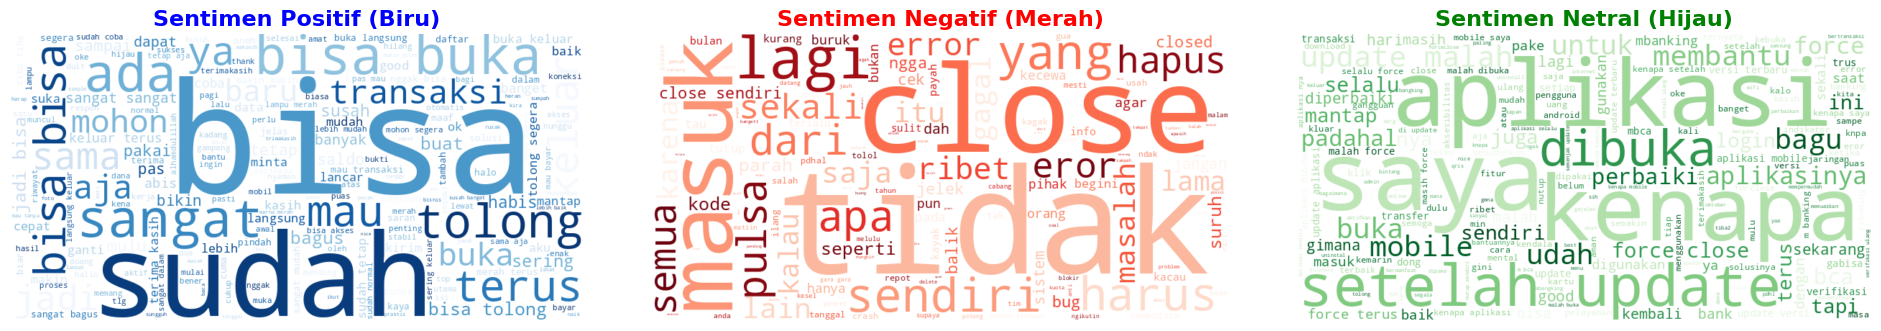

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# --- 1. Fungsi WordCloud dengan Kustomisasi Warna ---
def generate_sentiment_wordclouds(dataset_teks):
    all_pos_words = []
    all_neg_words = []
    all_neu_words = []

    for sentence in dataset_teks:
        for word in sentence:
            word = word.lower().strip()

            if word in lexicon_positive:
                all_pos_words.append(word)
            elif word in lexicon_negative:
                all_neg_words.append(word)
            else:
                # Filter kata netral (panjang > 3 karakter agar lebih bersih)
                if len(word) > 3:
                    all_neu_words.append(word)

    pos_text = " ".join(all_pos_words)
    neg_text = " ".join(all_neg_words)
    neu_text = " ".join(all_neu_words)

    plt.figure(figsize=(20, 7))

    # --- Plot Positif (Warna BIRU) ---
    plt.subplot(1, 3, 1)
    if pos_text:
        # Menggunakan colormap 'Blues'
        wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(pos_text)
        plt.imshow(wc_pos, interpolation='bilinear')
        plt.title('Sentimen Positif (Biru)', fontsize=16, fontweight='bold', color='blue')
    else:
        plt.text(0.5, 0.5, 'Tidak ditemukan', ha='center')
    plt.axis('off')

    # --- Plot Negatif (Warna MERAH) ---
    plt.subplot(1, 3, 2)
    if neg_text:
        # Menggunakan colormap 'Reds'
        wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(neg_text)
        plt.imshow(wc_neg, interpolation='bilinear')
        plt.title('Sentimen Negatif (Merah)', fontsize=16, fontweight='bold', color='red')
    else:
        plt.text(0.5, 0.5, 'Tidak ditemukan', ha='center')
    plt.axis('off')

    # --- Plot Netral (Warna HIJAU) ---
    plt.subplot(1, 3, 3)
    if neu_text:
        # Menggunakan colormap 'Greens'
        wc_neu = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(neu_text)
        plt.imshow(wc_neu, interpolation='bilinear')
        plt.title('Sentimen Netral (Hijau)', fontsize=16, fontweight='bold', color='green')
    else:
        plt.text(0.5, 0.5, 'Tidak ditemukan', ha='center')
    plt.axis('off')

    plt.tight_layout(pad=5.0)
    plt.show()

# --- 2. Proses Membaca Data BCA ---
file_name = 'scrapped_data_BCA.csv'

try:
    df = pd.read_csv(file_name)
    nama_kolom = 'content;' # Sesuaikan dengan nama kolom di CSV Anda

    if nama_kolom in df.columns:
        # Tokenisasi sederhana
        dataset_bca = df[nama_kolom].dropna().astype(str).apply(lambda x: x.lower().split()).tolist()
        print(f"Total data diproses: {len(dataset_bca)} baris.")

        # Jalankan Visualisasi
        generate_sentiment_wordclouds(dataset_bca)
    else:
        print(f"Error: Kolom '{nama_kolom}' tidak ditemukan.")

except FileNotFoundError:
    print(f"Error: File {file_name} tidak ditemukan.")
except Exception as e:
    print(f"Terjadi kesalahan: {e}")

# **VISUALISASI DIAGRAM LINGKARAN ULASAN SENTIMEN**

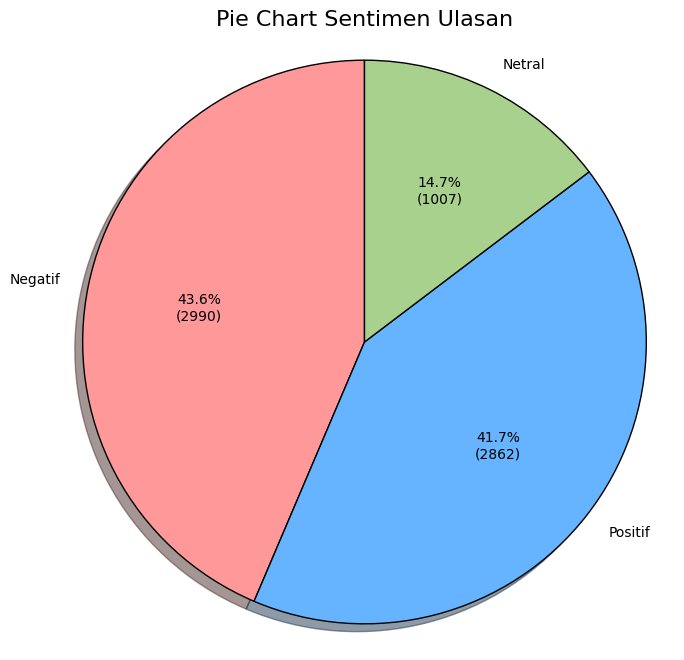

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np # Diperlukan untuk memastikan warna array

# Asumsi: clean_df sudah berisi kolom 'polarity' hasil analisis preprocessing/leksikon.

# 1. Mendapatkan Data Hitungan Kategori
polarity_counts = clean_df['polarity'].value_counts()

# 2. Menyiapkan Data untuk Plotting DENGAN URUTAN KHUSUS (Negatif, Positif, Netral)
# Dapatkan data untuk kategori yang diminati
try:
    sizes = [
        polarity_counts['negative'],
        polarity_counts['positive'],
        polarity_counts['neutral']
    ]
except KeyError:
    # Fallback jika nama label berbeda (misal: 'Negatif', 'Positif')
    # Sesuaikan ini jika Anda menggunakan label dengan huruf kapital/berbeda
    sizes = [
        polarity_counts.get('negative', 0),
        polarity_counts.get('positive', 0),
        polarity_counts.get('neutral', 0)
    ]

labels = ['Negatif', 'Positif', 'Netral']

# 3. Mendefinisikan Warna Sesuai Permintaan
# Negatif=Merah, Positif=Biru muda, Netral=hijau
colors = ['#ff9999', '#66b3ff', '#A9D18E']

# Fungsi untuk menampilkan persentase dan jumlah di dalam pie chart
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        # Format: Persentase (Jumlah)
        return f'{pct:.1f}%\n({val})'
    return my_autopct

# 4. Membuat Diagram Lingkaran (Pie Chart)
plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=make_autopct(sizes),
    startangle=90,
    shadow=True,
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Pie Chart Sentimen Ulasan', fontsize=16)
plt.axis('equal')
plt.show()

# **Ekstraksi Fitur Word2Vec**

proses pelatihan model Word2Vec untuk menghasilkan word embeddings dari data teks yang sudah dibersihkan (clean_df['text_akhir']). Pertama, data teks diekstrak dan diubah menjadi daftar kata (token) menggunakan fungsi tokenize_text. Kemudian, model Word2Vec diinisialisasi dengan beberapa parameter penting: vector_size=300 (menentukan dimensi vektor kata), window=5 (menentukan ukuran konteks), min_count=2 (mengabaikan kata yang muncul kurang dari 2 kali), sg=1 (Menggunakan Skip-gram. Algoritma ini bekerja dengan cara memprediksi kata-kata di sekitar (konteks) berdasarkan satu kata target), dan workers=4 (menggunakan 4 core CPU untuk pelatihan). Setelah membangun kosakata berdasarkan token yang dihasilkan, kode mencetak ukuran akhir kosakata yang telah difilter (hanya menyertakan kata dengan frekuensi minimal 5) dan melanjutkan pelatihan model selama 100 epoch. Akhirnya, model Word2Vec yang telah terlatih disimpan sebagai word2vec_model.model untuk digunakan dalam tugas-tugas NLP selanjutnya, seperti lapisan embedding pada model LSTM

In [ ]:
!pip install gensim
import pandas as pd
from gensim.utils import simple_preprocess
from gensim.models import Word2Vec

# Ambil data teks
texts = clean_df['text_akhir'].tolist()

def tokenize_text(text):
    return text.split()  # Mengembalikan daftar token (kata)

# Tokenisasi teks
tokenized_texts = [tokenize_text(text) for text in clean_df['text_akhir']]


# Latih model Word2Vec
model = Word2Vec(vector_size=300, window=5, min_count=2, sg=1, workers=4)

# Bangun vocabulary
model.build_vocab(tokenized_texts)

print(f"Vocabulary size: {len(model.wv)}")

# Latih model
model.train(tokenized_texts, total_examples=model.corpus_count, epochs=100)

# Simpan model
model.save("word2vec_model.model")

Vocabulary size: 1220


**Visualisasi hasil vektor Word2vec dengan 4 dimensi pertama**

In [ ]:
import pandas as pd
from gensim.models import Word2Vec

# 1. Memuat model yang sudah disimpan
# Gunakan nama variabel 'w2v_model' agar tidak tertimpa oleh model LSTM (Sequential)
w2v_model = Word2Vec.load("word2vec_model.model")

# 2. Mengambil 5 kata pertama dari vocabulary berdasarkan frekuensi tertinggi
top_words = sorted(w2v_model.wv.index_to_key,
                   key=lambda word: w2v_model.wv.get_vecattr(word, "count"),
                   reverse=True)[:5]

# 3. Menyusun data untuk tabel (No, Kata, dan 4 dimensi pertama vektor)
rekap_data = []
for i, word in enumerate(top_words, 1):
    # Mengambil 4 nilai pertama dari 300 dimensi yang tersedia
    v = w2v_model.wv[word][:4]
    rekap_data.append([i, word, v[0], v[1], v[2], v[3]])

# 4. Membuat DataFrame dengan nama kolom sesuai gambar
columns = ['No', 'Kata', 'Dimensi 1', 'Dimensi 2', 'Dimensi 3', 'Dimensi 4']
df_rekap = pd.DataFrame(rekap_data, columns=columns)

# 5. Menampilkan hasil
print("Model Word2Vec berhasil dimuat!")
print("Rekap Vektor Word2Vec (4 Dimensi Pertama):")
display(df_rekap)

Model Word2Vec berhasil dimuat!
Rekap Vektor Word2Vec (4 Dimensi Pertama):


,No,Kata,Dimensi 1,Dimensi 2,Dimensi 3,Dimensi 4
0,1,buka,-0.049615,0.070607,0.141560,0.254584
1,2,tidak,-0.065089,0.260038,-0.010785,0.100905
2,3,baca,0.058703,-0.009466,-0.019953,-0.222765
3,4,aplikasi,-0.501696,0.163255,-0.172983,0.211792
4,5,update,-0.147452,0.099610,0.167937,0.026444


# **Persiapan Data (Preprocessing) dan Pembuatan Embedding Matrix Menggunakan Word2Vec untuk Deep Learning**

tahapan feature extraction dan data preparation dalam alur kerja Natural Language Processing (NLP). Tujuannya adalah mengubah data teks mentah menjadi format numerik yang dapat dipahami oleh model Deep Learning (seperti LSTM, GRU, atau CNN) dengan memanfaatkan bobot vektor dari model Word2Vec yang sudah dilatih sebelumnya

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

model = Word2Vec.load("word2vec_model.model")

tokenizer = Tokenizer()
tokenizer.fit_on_texts(clean_df['text_akhir'])
sequences = tokenizer.texts_to_sequences(clean_df['text_akhir'])
word_index = tokenizer.word_index

# Buat matriks embedding
vocab_size = len(word_index) + 1
embedding_dim = model.vector_size  # Sesuaikan dengan dimensi model Word2Vec
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if word in model.wv:
        embedding_matrix[i] = model.wv[word]

print("Embedding matrix sample:")
print(embedding_matrix[:5])

Embedding matrix sample:
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [-0.04961464  0.07060695  0.14155978 ...  0.07825639  0.24145527
  -0.04339696]
 [-0.06508862  0.26003778 -0.01078512 ... -0.03126444 -0.08339264
  -0.19971223]
 [ 0.05870322 -0.00946639 -0.01995312 ...  0.25888637  0.08737113
  -0.12954989]
 [-0.50169557  0.16325536 -0.17298315 ...  0.07347728  0.00881446
  -0.26474956]]


# ***MODEL***

# **pembagian data 80/10/10**

---



In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X_sequences = tokenizer.texts_to_sequences(clean_df['text_akhir'])
max_length = max(len(seq) for seq in X_sequences)
X_padded = pad_sequences(X_sequences, maxlen=max_length)

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(clean_df['polarity'])

# Tambahkan ini setelah baris y_encoded
for index, label in enumerate(label_encoder.classes_):
    print(f"Indeks {index}: {label}")

Indeks 0: negative
Indeks 1: neutral
Indeks 2: positive


In [ ]:
# Split pertama: 80% train, 20% sementara (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_padded, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded)

# Split kedua: 20% dibagi rata → 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp)

print(f"Data Latih    : {len(X_train)} ({len(X_train)/len(X_padded)*100:.0f}%)")
print(f"Data Validasi : {len(X_val)} ({len(X_val)/len(X_padded)*100:.0f}%)")
print(f"Data Uji      : {len(X_test)} ({len(X_test)/len(X_padded)*100:.0f}%)")

Data Latih    : 5487 (80%)
Data Validasi : 686 (10%)
Data Uji      : 686 (10%)


# **Visualisasi pembagian data**

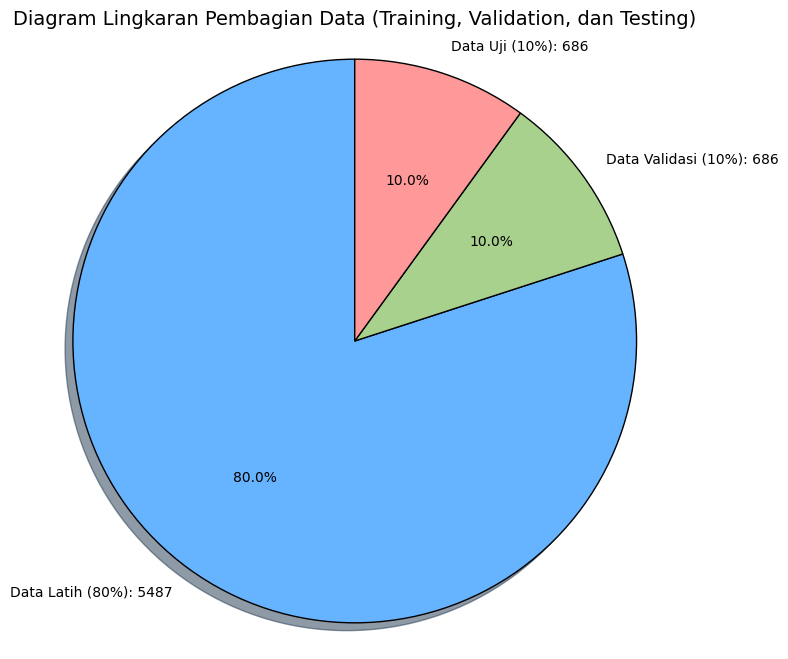

In [ ]:
# --- Visualisasi Pembagian Data (Diagram Lingkaran) ---

# 1. Menyiapkan Data Visualisasi
sizes  = [len(X_train), len(X_val), len(X_test)]
# Label mencantumkan persentase dan jumlah ulasan
labels = [f'Data Latih (80%): {len(X_train)}',
          f'Data Validasi (10%): {len(X_val)}',
          f'Data Uji (10%): {len(X_test)}']
colors = ['#66b3ff', '#A9D18E', '#ff9999']

# Fungsi untuk menampilkan persentase di dalam irisan
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%'
    return my_autopct

# 2. Membuat Diagram Lingkaran
plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=make_autopct(sizes),
    startangle=90,             # Memulai irisan pertama dari atas
    shadow=True,
    wedgeprops={'edgecolor': 'black'} # Garis tepi untuk pemisah yang jelas
)

plt.title('Diagram Lingkaran Pembagian Data (Training, Validation, dan Testing)', fontsize=14)
plt.axis('equal') # Memastikan bentuk lingkaran sempurna
plt.show()

# **Pembangunan Arsitektur Model LSTM**

tahap konstruksi arsitektur dan pelatihan model Deep Learning untuk klasifikasi teks multikelas (sentimen Positif, Netral, dan Negatif). Arsitektur utamanya berbasis LSTM bertingkat, yang memungkinkan model mempelajari urutan kata guna menangkap konteks semantik yang lebih komprehensif.

**Training**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_model(vocab_size, embedding_matrix, max_length):
    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=300,
                  weights=[embedding_matrix],
                  input_length=max_length,
                  trainable=True),

        LSTM(64, return_sequences=True),
        Dropout(0.3),

        LSTM(32),
        Dropout(0.3),

        Dense(16, activation='relu'),
        Dropout(0.3),

        Dense(3, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=1e-4),
        metrics=['accuracy']
    )
    return model

# Panggil fungsi untuk membuat model
model = build_model(vocab_size, embedding_matrix, max_length)

**callback**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def get_callbacks():
    checkpoint_filepath = 'best_model.keras'

    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1 # Memberikan log saat model disimpan
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    return [checkpoint, early_stop]

**validasi**

In [ ]:
# Menyiapkan callbacks
my_callbacks = get_callbacks()

# Menjalankan proses Pelatihan & Validasi
history = model.fit(
    X_train, y_train,
    epochs=100, batch_size=32,
    validation_data=(X_val, y_val), # <--- Proses Validasi terjadi di sini menggunakan data validasi
    callbacks=my_callbacks,
    verbose=1
)

Epoch 1/100
168/172 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4423 - loss: 1.0305
Epoch 1: val_loss improved from None to 0.94298, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4779 - loss: 1.0006 - val_accuracy: 0.5889 - val_loss: 0.9430
Epoch 2/100
169/172 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5556 - loss: 0.9389
Epoch 2: val_loss improved from 0.94298 to 0.86914, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5712 - loss: 0.9320 - val_accuracy: 0.6399 - val_loss: 0.8691
Epoch 3/100
170/172 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6361 - loss: 0.8615
Epoch 3: val_loss improved from 0.86914 to 0.75585, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6508 - loss: 0.8493 - val_accuracy: 

# **VISUALISASI GRAFIK AKURASI DAN LOSS**

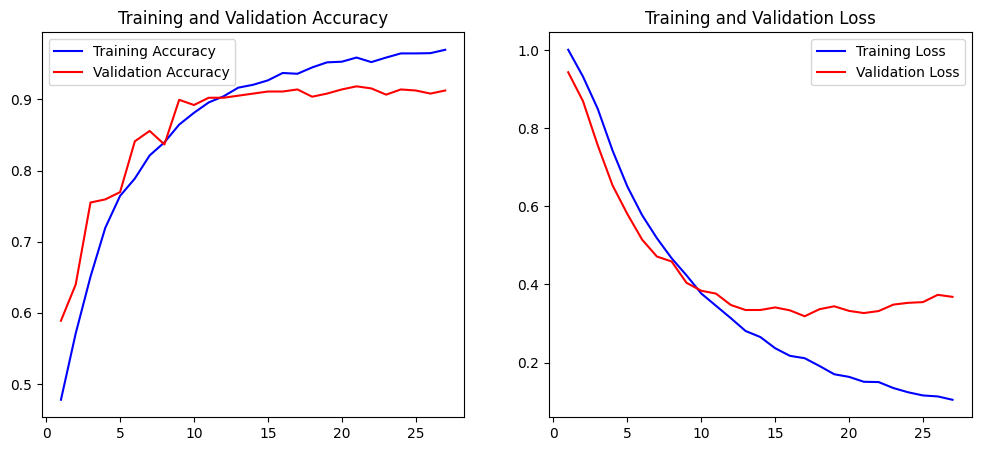

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Grafik Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Grafik Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

# Panggil fungsi setelah model.fit selesai
# history = model.fit(...)
plot_history(history)

# **Evaluasi model pada data training dan testing**

melakukan evaluasi akhir terhadap kinerja model deep learning yang telah dilatih. Pertama, model dievaluasi pada data pelatihan (X_train, y_train) untuk mendapatkan nilai kerugian (loss_train) dan akurasi pelatihan (accuracy_train), yang kemudian dicetak sebagai persentase. Selanjutnya, langkah yang paling krusial adalah evaluasi model pada data pengujian (X_test, y_test) yang belum pernah dilihat model selama pelatihan. Ini menghasilkan nilai kerugian (loss) dan akurasi pengujian (accuracy), yang mencerminkan kemampuan generalisasi model pada data baru. Hasil akurasi pengujian ini adalah metrik utama yang digunakan untuk menilai seberapa efektif model dalam menyelesaikan tugas

In [ ]:
# Evaluasi model pada data training dan testing
loss_train, accuracy_train = model.evaluate(X_train, y_train)
print(f"Training Accuracy: {accuracy_train * 100:.2f}%")

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Testing Accuracy: {accuracy * 100:.2f}%")

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9685 - loss: 0.1163
Training Accuracy: 96.85%
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9184 - loss: 0.2888
Testing Accuracy: 91.84%


# ***ASSESS***

**MODEL TESTING & PREDICTION**

**CONFUSION MATIRX**

mengevaluasi kinerja akhir model klasifikasi pada data pengujian (X_test) dan menyajikan hasilnya secara detail menggunakan Classification Report.

In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Muat model terbaik yang disimpan oleh ModelCheckpoint
model = load_model('best_model.keras')

# 2. Evaluasi model menggunakan data test
# Ini akan memberikan nilai Loss dan Akurasi akhir
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Hasil Evaluasi - Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

# 3. Prediksi data test
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1) # Mengambil indeks dengan probabilitas tertinggi

# 4. Membuat Classification Report (Precision, Recall, F1-Score)
target_names = ['Negatif', 'Netral', 'Positif']
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Hasil Evaluasi - Loss: 0.2888, Accuracy: 0.9184
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.93      0.94      0.94       299
      Netral       0.84      0.80      0.82       101
     Positif       0.93      0.93      0.93       286

    accuracy                           0.92       686
   macro avg       0.90      0.89      0.90       686
weighted avg       0.92      0.92      0.92       686



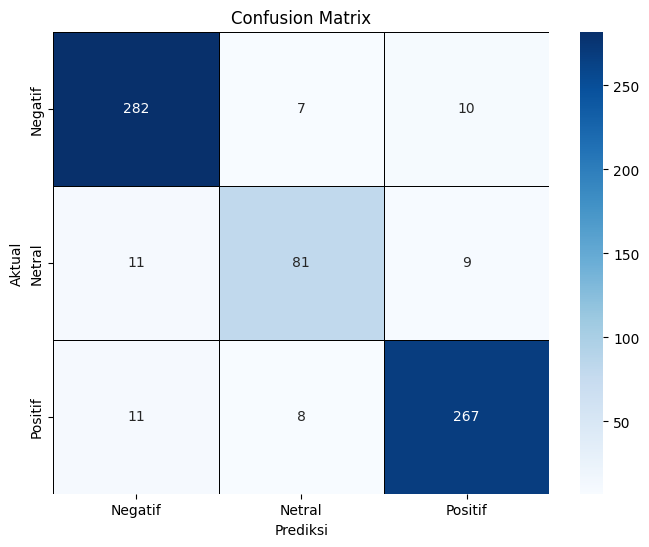

In [ ]:
# 5. Membuat Confusion Matrix untuk melihat salah prediksi di kelas mana
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, linecolor='black')

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')

plt.show()

**Visualisasi dengan diagram lingkaran**

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


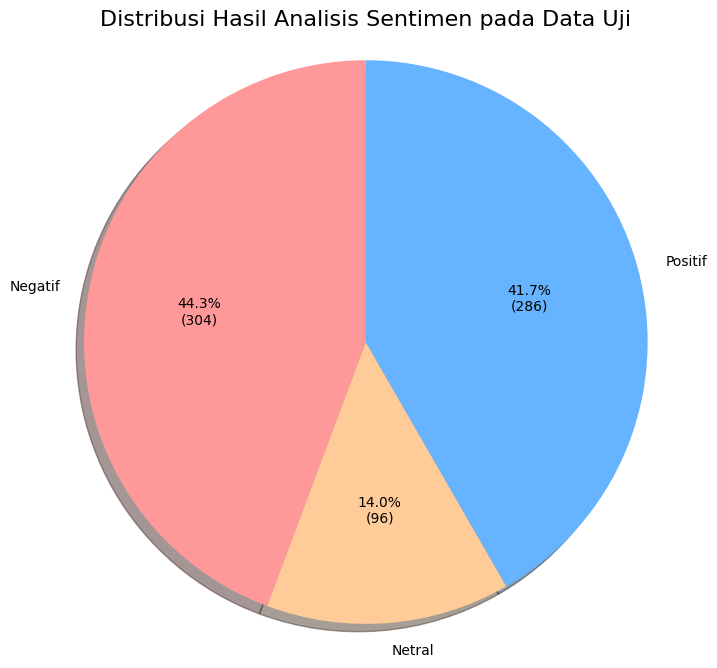


Matriks Kebingungan (Prediksi vs. Aktual):
[[282   7  10]
 [ 11  81   9]
 [ 11   8 267]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix # Opsional, untuk melihat label sebenarnya

# --- 1. Mendapatkan Prediksi Model ---
# Dapatkan probabilitas prediksi untuk setiap ulasan di data testing
y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

# --- 2. Menghitung Jumlah Prediksi per Kelas ---
sentiment_counts = np.bincount(y_pred)

# Pastikan array memiliki 3 elemen, tambahkan nol jika ada kelas yang tidak terprediksi
# (Ini penting jika np.bincount hanya mengembalikan 2 elemen)
if len(sentiment_counts) < 3:
    # Padding dengan nol jika kurang dari 3
    padded_counts = np.zeros(3, dtype=int)
    padded_counts[:len(sentiment_counts)] = sentiment_counts
    sentiment_counts = padded_counts

# --- 3. Menyiapkan Data untuk Plotting ---
labels = ['Negatif', 'Netral', 'Positif']
sizes = sentiment_counts
colors = ['#ff9999', '#ffcc99', '#66b3ff'] # Warna merah, oranye, biru muda

# Hitung persentase untuk label di pie chart
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.1f}%\n({val})'
    return my_autopct

# --- 4. Membuat Diagram Lingkaran ---
plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=make_autopct(sizes), # Menampilkan persentase dan hitungan
    startangle=90,              # Memulai slice pertama dari atas
    shadow=True
)

plt.title('Distribusi Hasil Analisis Sentimen pada Data Uji', fontsize=16)
plt.axis('equal') # Memastikan pie chart berbentuk lingkaran sempurna
plt.show()

#--- Tambahan: Tampilkan Matriks Kebingungan (Opsional) ---
#Matriks kebingungan menunjukkan kinerja aktual model vs. label sebenarnya
print("\nMatriks Kebingungan (Prediksi vs. Aktual):")
print(confusion_matrix(y_test, y_pred))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Get the original text data corresponding to X_padded
original_texts = clean_df['text_akhir'] # This is a Series

# Re-perform the train-test split for the original texts to get the test set texts
# Using the same random_state and stratify ensures the split is consistent with X_test and y_test
_, X_temp_txt, _, _ = train_test_split(
    original_texts, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded)

# Split kedua untuk mendapatkan teks yang sesuai X_test
_, teks_test_series, _, _ = train_test_split(
    X_temp_txt, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp)

# Convert teks_test_series to a list so it can be indexed by integer positions (0 to len-1)
# corresponding to the `errors` array.
teks_test = teks_test_series.tolist()


# 1. Melakukan prediksi (pastikan y_pred sudah ada dari Kode 4)

# 2. Cari indeks di mana prediksi tidak sama dengan label aktual
errors = np.where(y_pred != y_test)[0]

print(f"Total kesalahan prediksi: {len(errors)} dari {len(y_test)} data test.\n")

# 3. Ambil teks asli dari data test
results_df = pd.DataFrame({
    'No': range(1, len(errors) + 1),
    'Kalimat Asli': [teks_test[i] for i in errors],
    'Label Aktual': [target_names[y_test[i]] for i in errors],
    'Prediksi Model': [target_names[y_pred[i]] for i in errors]
})

# 1. Menampilkan 10 kesalahan pertama secara umum
print("--- 10 CONTOH KESALAHAN PREDIKSI UMUM ---")
display(results_df.head(20).style.set_properties(**{'text-align': 'left'}))

# # 2. Menampilkan kesalahan spesifik (Seharusnya Positif tapi diprediksi Negatif)
# print("\n--- ANALISIS: SEHARUSNYA POSITIF TAPI DIPREDIKSI NEGATIF ---")
# false_negatives = results_df[(results_df['Label Aktual'] == 'Positif') & (results_df['Prediksi Model'] == 'Negatif')]

# if not false_negatives.empty:
#     display(false_negatives.head(10))
# else:
#     print("Tidak ditemukan kesalahan pada kategori ini.")

Total kesalahan prediksi: 60 dari 686 data test.

--- 10 CONTOH KESALAHAN PREDIKSI UMUM ---


,No,Kalimat Asli,Label Aktual,Prediksi Model
0,1,aplikasi ringan nyaman,Positif,Netral
1,2,banget ngebug keluar gilir dibutuhin suruh telpon cs ngerepotin banget,Positif,Negatif
2,3,service tiada dua,Negatif,Netral
3,4,baca tolong baik aplikasi close forece instal ulang kali close force hubung halo baca kasih close force,Netral,Negatif
4,5,baca buka mbanking sulit,Negatif,Positif
5,6,aplikasi muncul dihp,Netral,Negatif
6,7,bagus mantap,Negatif,Positif
7,8,foto wajah,Positif,Negatif
8,9,enak,Netral,Negatif
9,10,forclose muluu tololl,Netral,Negatif
